# 5.3 Final Independent Community Test Evaluation

After model selection on the 500-patient development cohort, simple ECG–PCG
concatenation fusion was selected as the final multimodal architecture.

This notebook evaluates the selected model once on the independent community
test cohort.

No model architecture, hyperparameter, or decision threshold is tuned using
the test set. The five fold-specific fusion models are ensembled by averaging
their predicted probabilities, and thresholds selected from development data
are applied unchanged.

In [1]:
from pathlib import Path
import sys
import json
import torch
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

Project root: C:\Users\Dell\Documents\Deep_Learning\ecg-pcg-fusion-hfref
Device: CPU


In [2]:
import importlib

import src.fusion_model as fusion_model
import src.fusion_five_fold as fusion_five_fold

importlib.reload(fusion_model)
importlib.reload(fusion_five_fold)

print("Modules loaded successfully.")

Modules loaded successfully.


c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
concat_model_root = (
    PROJECT_ROOT
    / "models"
    / "five_fold_cross_validation"
    / "fusion_concat_seed42"
)

for fold in range(5):
    checkpoint = (
        concat_model_root
        / f"fold_{fold}"
        / "best_model.pt"
    )

    settings = (
        concat_model_root
        / f"fold_{fold}"
        / "settings.json"
    )

    print(
        f"Fold {fold}:",
        "checkpoint =", checkpoint.is_file(),
        "| settings =", settings.is_file()
    )

Fold 0: checkpoint = True | settings = True
Fold 1: checkpoint = True | settings = True
Fold 2: checkpoint = True | settings = True
Fold 3: checkpoint = True | settings = True
Fold 4: checkpoint = True | settings = True


In [4]:
from src.five_fold_validation import _load_metadata

development_df, _ = _load_metadata(
    PROJECT_ROOT,
    "development"
)

test_df, _ = _load_metadata(
    PROJECT_ROOT,
    "test"
)

overlap = set(development_df.Patient_ID) & set(test_df.Patient_ID)

print("Development patients:", len(development_df))
print("Test patients:", len(test_df))
print("Test HFrEF patients:", int(test_df.Label.sum()))
print("Patient overlap:", len(overlap))

Development patients: 500
Test patients: 120
Test HFrEF patients: 5
Patient overlap: 0


In [5]:
test_result_dir = (
    fusion_five_fold.evaluate_fusion_ensemble_on_test(
        project_dir=PROJECT_ROOT,
        architecture="concat",
        encoder_seed=42,
        fusion_seed=42,
        batch_size=16,
    )
)

print("Test results saved to:")
print(test_result_dir)

Test results saved to:
C:\Users\Dell\Documents\Deep_Learning\ecg-pcg-fusion-hfref\analysis_outputs\five_fold_cross_validation\fusion_concat_seed42


In [6]:
test_results_path = (
    PROJECT_ROOT
    / "analysis_outputs"
    / "five_fold_cross_validation"
    / "fusion_concat_seed42"
    / "community_test_results.csv"
)

test_results = pd.read_csv(
    test_results_path
)

display(
    test_results.round(4)
)

,model,cutoff_rule,development_cutoff,test_patients,test_hfref_patients,test_threshold,test_auprc,test_auroc,test_recall,test_specificity,...,test_precision,test_f1,test_brier,test_log_loss,test_calibration_error,test_tn,test_fp,test_fn,test_tp,result_source
0,Five-fold concat fusion ensemble,maximum_development_f1,0.5773,120,5,0.5773,0.925,0.9948,0.8,0.9913,...,0.8000,0.8000,0.0409,0.19,0.1471,114,1,1,4,five_model_probability_average
1,Five-fold concat fusion ensemble,target_90pct_development_specificity,0.4656,120,5,0.4656,0.925,0.9948,0.8,0.9739,...,0.5714,0.6667,0.0409,0.19,0.1471,112,3,1,4,five_model_probability_average


In [7]:
predictions_path = (
    PROJECT_ROOT
    / "analysis_outputs"
    / "five_fold_cross_validation"
    / "fusion_concat_seed42"
    / "community_test_ensemble_predictions.csv"
)

test_predictions = pd.read_csv(
    predictions_path
)

display(
    test_predictions.head(10)
)

,Patient_ID,LVEF,Label,Probability,model,cutoff_rule,Prediction,Cutoff
0,1011486422,0.40,1,0.705692,Five-fold concat fusion ensemble,maximum_development_f1,True,0.577267
1,2024031801,0.58,0,0.073158,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
2,2024031802,0.61,0,0.074348,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
3,2024031803,0.61,0,0.176931,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
4,2024031804,0.62,0,0.357640,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
5,2024031805,0.57,0,0.381375,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
6,2024031806,0.59,0,0.082168,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
7,2024031807,0.52,0,0.117991,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
8,2024031809,0.61,0,0.072607,Five-fold concat fusion ensemble,maximum_development_f1,False,0.577267
9,2024031810,0.63,0,0.623993,Five-fold concat fusion ensemble,maximum_development_f1,True,0.577267


In [8]:
development_summary = pd.read_csv(
    PROJECT_ROOT
    / "analysis_outputs"
    / "five_fold_cross_validation"
    / "fusion_concat_seed42"
    / "development_summary.csv"
)

display(
    development_summary[
        [
            "cutoff_rule",
            "auroc",
            "auprc",
            "balanced_accuracy",
            "precision",
            "f1",
        ]
    ].round(4)
)

display(
    test_results.round(4)
)

,cutoff_rule,auroc,auprc,balanced_accuracy,precision,f1
0,maximum_development_f1,0.9034,0.5735,0.7894,0.6129,0.6230
1,target_90pct_development_specificity,0.9034,0.5735,0.8167,0.5000,0.5946


,model,cutoff_rule,development_cutoff,test_patients,test_hfref_patients,test_threshold,test_auprc,test_auroc,test_recall,test_specificity,...,test_precision,test_f1,test_brier,test_log_loss,test_calibration_error,test_tn,test_fp,test_fn,test_tp,result_source
0,Five-fold concat fusion ensemble,maximum_development_f1,0.5773,120,5,0.5773,0.925,0.9948,0.8,0.9913,...,0.8000,0.8000,0.0409,0.19,0.1471,114,1,1,4,five_model_probability_average
1,Five-fold concat fusion ensemble,target_90pct_development_specificity,0.4656,120,5,0.4656,0.925,0.9948,0.8,0.9739,...,0.5714,0.6667,0.0409,0.19,0.1471,112,3,1,4,five_model_probability_average


In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

BASE = (
    PROJECT_ROOT
    / "analysis_outputs"
    / "five_fold_cross_validation"
)

DEV_OOF_PATH = (
    BASE
    / "fusion_concat_seed42"
    / "development_oof_predictions.csv"
)

TEST_PRED_PATH = (
    BASE
    / "fusion_concat_seed42"
    / "community_test_ensemble_predictions.csv"
)

DEV_SUMMARY_PATH = (
    BASE
    / "fusion_concat_seed42"
    / "development_summary.csv"
)

TEST_RESULTS_PATH = (
    BASE
    / "fusion_concat_seed42"
    / "community_test_results.csv"
)

FIGURE_DIR = (
    BASE
    / "fusion_concat_seed42"
    / "final_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Figures will be saved to:")
print(FIGURE_DIR)

Figures will be saved to:
C:\Users\Dell\Documents\Deep_Learning\ecg-pcg-fusion-hfref\analysis_outputs\five_fold_cross_validation\fusion_concat_seed42\final_figures


In [10]:
dev_oof = pd.read_csv(
    DEV_OOF_PATH
)

test_all = pd.read_csv(
    TEST_PRED_PATH
)

test_pred = (
    test_all[
        test_all["cutoff_rule"]
        == "maximum_development_f1"
    ]
    .drop_duplicates("Patient_ID")
    .reset_index(drop=True)
)

print("Development patients:", len(dev_oof))
print("Test patients:", len(test_pred))

print(
    "Development positives:",
    int(dev_oof["Label"].sum())
)

print(
    "Test positives:",
    int(test_pred["Label"].sum())
)

Development patients: 500
Test patients: 120
Development positives: 60
Test positives: 5


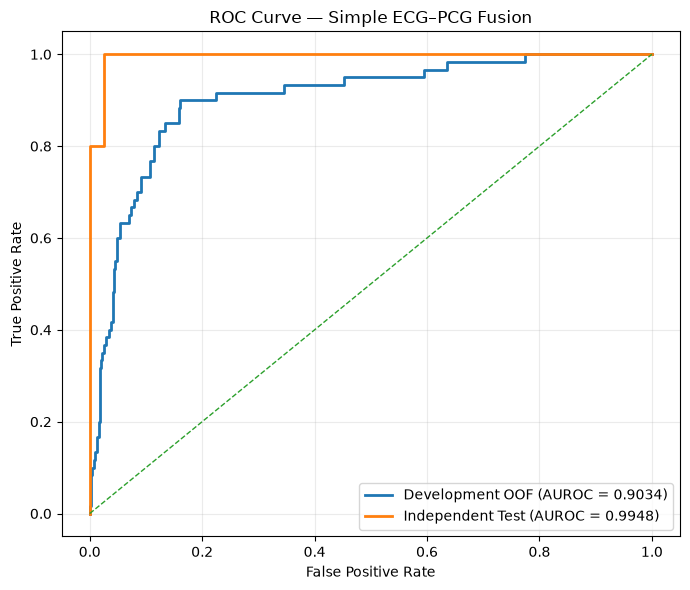

In [11]:
dev_fpr, dev_tpr, _ = roc_curve(
    dev_oof["Label"],
    dev_oof["Probability"],
)

test_fpr, test_tpr, _ = roc_curve(
    test_pred["Label"],
    test_pred["Probability"],
)

dev_auc = roc_auc_score(
    dev_oof["Label"],
    dev_oof["Probability"],
)

test_auc = roc_auc_score(
    test_pred["Label"],
    test_pred["Probability"],
)

plt.figure(figsize=(7, 6))

plt.plot(
    dev_fpr,
    dev_tpr,
    linewidth=2,
    label=f"Development OOF (AUROC = {dev_auc:.4f})",
)

plt.plot(
    test_fpr,
    test_tpr,
    linewidth=2,
    label=f"Independent Test (AUROC = {test_auc:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Simple ECG–PCG Fusion"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

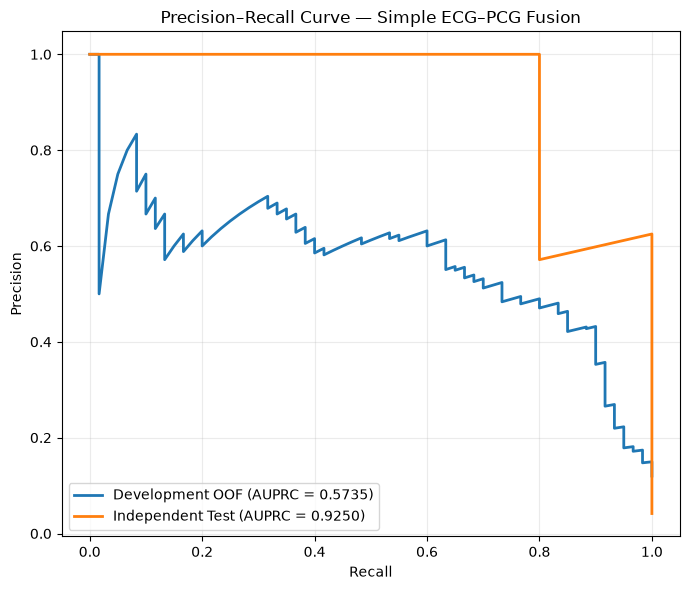

In [12]:
dev_precision, dev_recall, _ = (
    precision_recall_curve(
        dev_oof["Label"],
        dev_oof["Probability"],
    )
)

test_precision, test_recall, _ = (
    precision_recall_curve(
        test_pred["Label"],
        test_pred["Probability"],
    )
)

dev_ap = average_precision_score(
    dev_oof["Label"],
    dev_oof["Probability"],
)

test_ap = average_precision_score(
    test_pred["Label"],
    test_pred["Probability"],
)

plt.figure(figsize=(7, 6))

plt.plot(
    dev_recall,
    dev_precision,
    linewidth=2,
    label=f"Development OOF (AUPRC = {dev_ap:.4f})",
)

plt.plot(
    test_recall,
    test_precision,
    linewidth=2,
    label=f"Independent Test (AUPRC = {test_ap:.4f})",
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Curve — Simple ECG–PCG Fusion"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Development-derived cutoff: 0.5772667229175568

Confusion matrix:
[[114   1]
 [  1   4]]


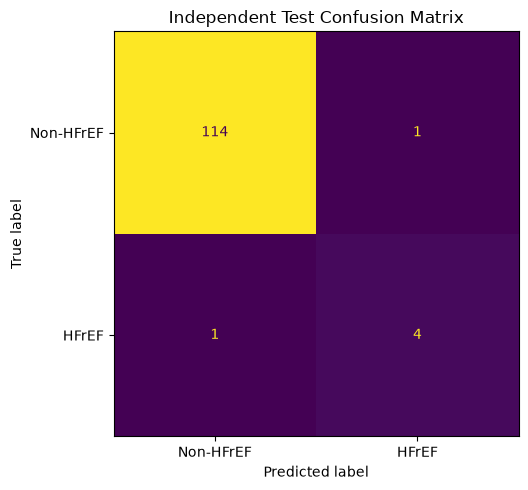

In [13]:
test_results = pd.read_csv(
    TEST_RESULTS_PATH
)

primary_result = test_results[
    test_results["cutoff_rule"]
    == "maximum_development_f1"
].iloc[0]

cutoff = float(
    primary_result["development_cutoff"]
)

test_prediction = (
    test_pred["Probability"] >= cutoff
).astype(int)

cm = confusion_matrix(
    test_pred["Label"],
    test_prediction,
)

print("Development-derived cutoff:", cutoff)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-HFrEF",
        "HFrEF",
    ],
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "Independent Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
dev_summary = pd.read_csv(
    DEV_SUMMARY_PATH
)

test_results = pd.read_csv(
    TEST_RESULTS_PATH
)

dev_primary = dev_summary[
    dev_summary["cutoff_rule"]
    == "maximum_development_f1"
].iloc[0]

test_primary = test_results[
    test_results["cutoff_rule"]
    == "maximum_development_f1"
].iloc[0]

summary_table = pd.DataFrame({
    "Metric": [
        "Patients",
        "HFrEF patients",
        "AUROC",
        "AUPRC",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1",
        "Balanced Accuracy",
        "Brier Score",
        "Log Loss",
    ],

    "Development OOF": [
        int(dev_primary["patients"]),
        int(dev_primary["hfref_patients"]),
        dev_primary["auroc"],
        dev_primary["auprc"],
        dev_primary["recall"],
        dev_primary["specificity"],
        dev_primary["precision"],
        dev_primary["f1"],
        dev_primary["balanced_accuracy"],
        dev_primary["brier"],
        dev_primary["log_loss"],
    ],

    "Independent Test": [
        int(test_primary["test_patients"]),
        int(test_primary["test_hfref_patients"]),
        test_primary["test_auroc"],
        test_primary["test_auprc"],
        test_primary["test_recall"],
        test_primary["test_specificity"],
        test_primary["test_precision"],
        test_primary["test_f1"],
        test_primary["test_balanced_accuracy"],
        test_primary["test_brier"],
        test_primary["test_log_loss"],
    ],
})

display(
    summary_table.round(4)
)

,Metric,Development OOF,Independent Test
0,Patients,500.0000,120.0000
1,HFrEF patients,60.0000,5.0000
2,AUROC,0.9034,0.9948
3,AUPRC,0.5735,0.9250
4,Sensitivity,0.6333,0.8000
5,Specificity,0.9455,0.9913
6,Precision,0.6129,0.8000
7,F1,0.6230,0.8000
8,Balanced Accuracy,0.7894,0.8957
9,Brier Score,0.0825,0.0409


In [15]:
summary_table.to_csv(
    FIGURE_DIR
    / "development_vs_independent_test.csv",
    index=False,
)

print("Saved final outputs:")
print(FIGURE_DIR)

Saved final outputs:
C:\Users\Dell\Documents\Deep_Learning\ecg-pcg-fusion-hfref\analysis_outputs\five_fold_cross_validation\fusion_concat_seed42\final_figures
